In [1]:
import pandas as pd
import joblib

df = pd.read_csv("../data/processed/telco_ml_ready.csv")

model = joblib.load("../models/churn_model.pkl")

y = df["Churn"]
X = df.drop(columns=["Churn"], errors="ignore")

X = pd.get_dummies(X, drop_first=True)

In [2]:
train_cols = model.feature_names_in_

X = X.reindex(columns=train_cols, fill_value=0)

In [3]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

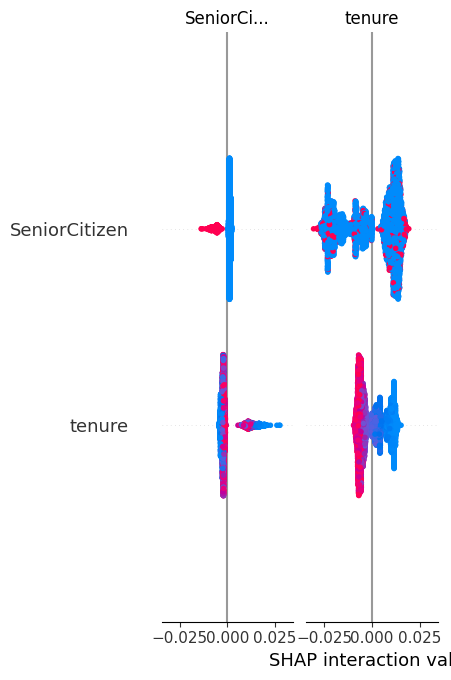

In [4]:
shap.summary_plot(shap_values, X)

In [5]:
idx = X[y==1].index[0]

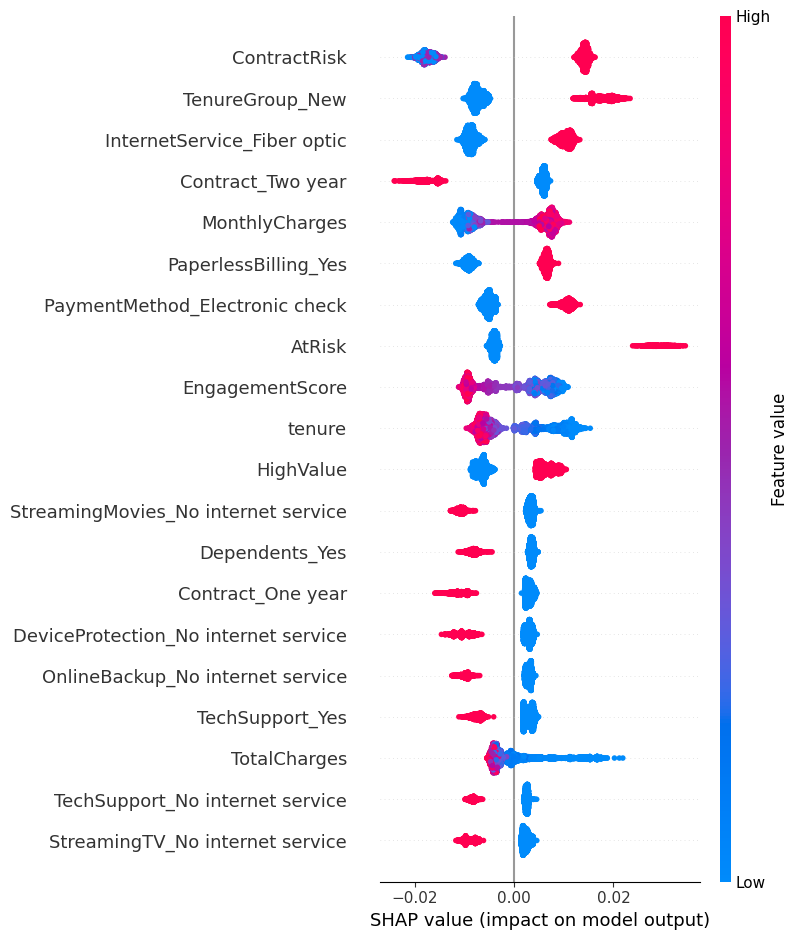

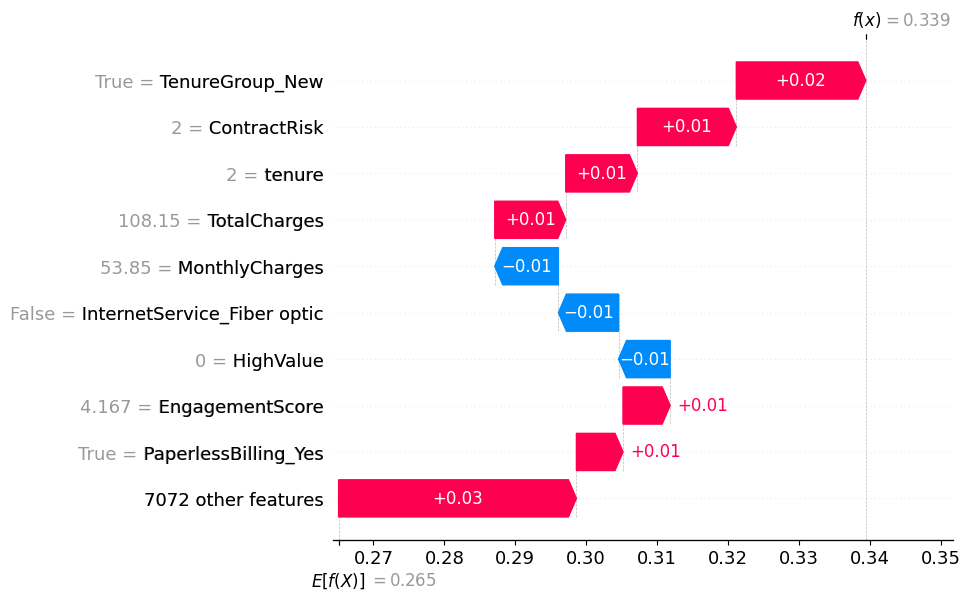

In [13]:
import shap
import numpy as np

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# ---- Handle different SHAP formats safely ----
if isinstance(shap_values, list):
    shap_churn = shap_values[1]
    base_value = explainer.expected_value[1]
elif len(np.array(shap_values).shape) == 3:
    shap_churn = shap_values[:,:,1]
    base_value = explainer.expected_value[1]
else:
    shap_churn = shap_values
    base_value = explainer.expected_value

# ---- Global importance ----
shap.summary_plot(shap_churn, X)

# ---- One churned customer ----
idx = X[y==1].index[0]

shap.force_plot(
    base_value,
    shap_churn[idx],
    X.loc[idx]
)

# ---- Waterfall ----
shap.plots.waterfall(
    shap.Explanation(
        values=shap_churn[idx],
        base_values=base_value,
        data=X.loc[idx],
        feature_names=X.columns
    )
)

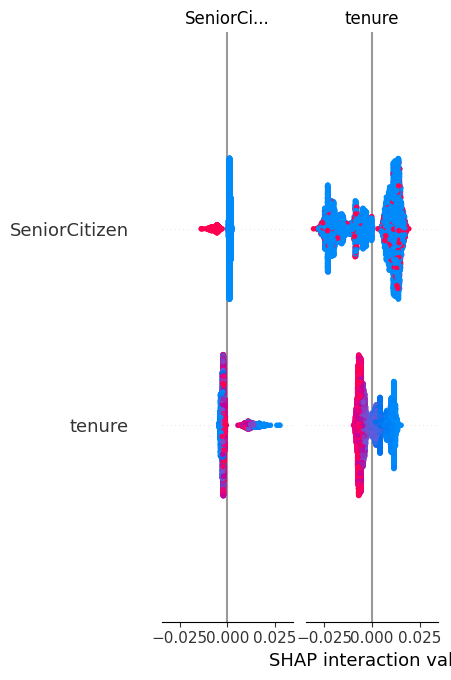

In [14]:
shap.summary_plot(shap_values, X, show=False)
import matplotlib.pyplot as plt
plt.savefig("../models/shap_summary.png")